In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


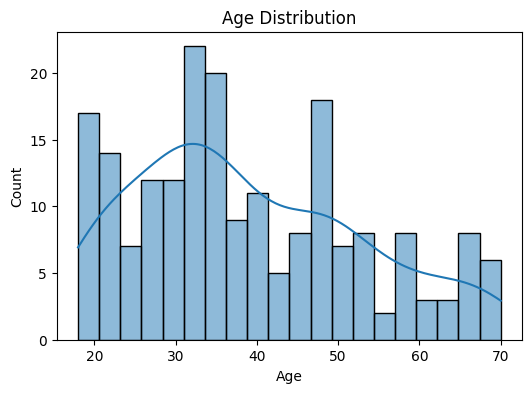

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

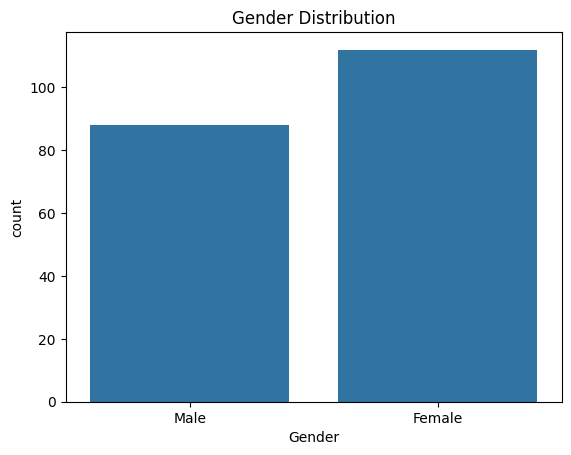

In [6]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

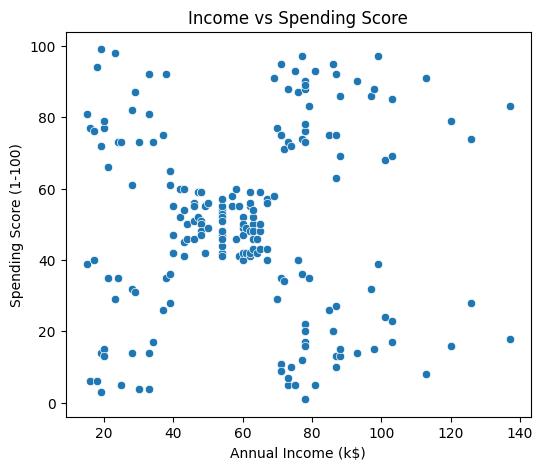

In [7]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

In [8]:
X = df[['Age','Annual Income (k$)', 'Spending Score (1-100)']]

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

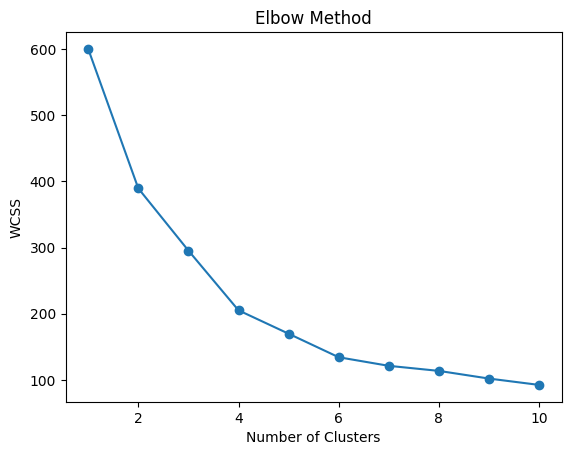

In [10]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
from sklearn.metrics import silhouette_score

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print("Clusters:", i, "Score:", score)

Clusters: 2 Score: 0.33547192894004574
Clusters: 3 Score: 0.3579234303882264
Clusters: 4 Score: 0.4039582785148566
Clusters: 5 Score: 0.40846873777345605
Clusters: 6 Score: 0.43106526216603014
Clusters: 7 Score: 0.410091114520974
Clusters: 8 Score: 0.3673663165322295
Clusters: 9 Score: 0.37442148555078425
Clusters: 10 Score: 0.36186970479722974


In [23]:
kmeans = KMeans(n_clusters=6, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

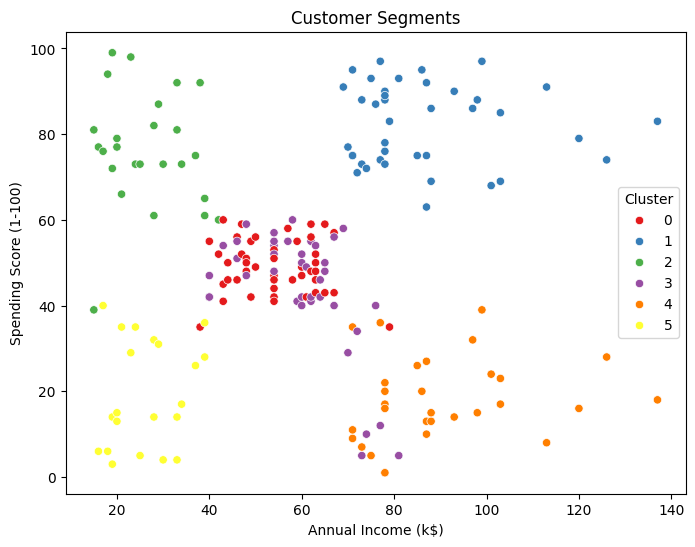

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

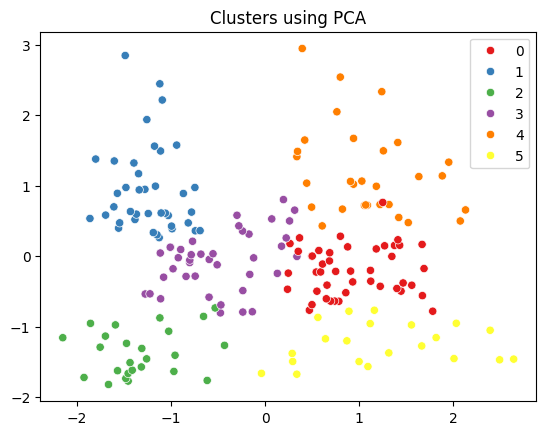

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_kmeans, palette='Set1')
plt.title("Clusters using PCA")
plt.show()

In [22]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("Cluster Centers:")
print(centers)

Cluster Centers:
[[55.27586207 47.62068966 41.70689655]
 [32.875      86.1        81.525     ]
 [25.76923077 26.11538462 74.84615385]
 [26.73333333 54.31111111 40.91111111]
 [44.38709677 89.77419355 18.48387097]]
